# Chapter 10 Physics-Informed Neural Network
## Rahul Bhadani

# 1. Example 1

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class PINN(nn.Module):
    def __init__(self, hidden_size: int = 20):
        super().__init__()

        # Network layers
        self.layer1 = nn.Linear(1, hidden_size)
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        self.layer3 = nn.Linear(hidden_size, 1)

        # Activation
        self.activation = nn.Tanh()

        self._init_weights()
    
    def _init_weights(self):
        for layer in [self.layer1, self.layer2, self.layer3]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        x = self.layer3(x)
        return x        
    
    
    def ode_residual(self, x: torch.Tensor) -> torch.Tensor:
        """Computes  dy/dx + 2y  at every collocation point x."""
        y = self.forward(x)
        dy_dx = torch.autograd.grad(
            outputs      = y,
            inputs       = x,
            grad_outputs = torch.ones_like(y),
            create_graph = True,        # needed so .backward() reaches weights
        )[0]
        return dy_dx + 2.0 * y
    
    
    def ic_residual(self) -> torch.Tensor:
        """Computes  (y(0) − 1)^2  — the initial-condition penalty."""
        x0 = torch.zeros(1, 1)
        return (self.forward(x0) - 1.0) ** 2
    
    
    def loss(
        self,
        x: torch.Tensor,
        lambda_ode: float = 1.0,
        lambda_ic:  float = 10.0,       # weight IC more heavily
    ) -> torch.Tensor:
        
        loss_ode = lambda_ode * torch.mean(self.ode_residual(x) ** 2)
        loss_ic  = lambda_ic  * self.ic_residual()
        return loss_ode + loss_ic

In [3]:
model     = PINN(hidden_size=20)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [14]:
# Collocation points — requires_grad so autograd can differentiate w.r.t. x
#x_train = torch.linspace(0, 2, 100).view(-1, 1).requires_grad_(True)

x_train = torch.rand(10, 1) * 2   # 10 random points in [0, 2]
x_train.requires_grad_(True)

tensor([[1.5033],
        [0.7867],
        [0.8452],
        [1.9677],
        [0.4309],
        [0.5800],
        [1.6497],
        [1.0773],
        [1.5811],
        [0.5171]], requires_grad=True)

In [15]:
loss_history = []

for epoch in range(100000):
    optimizer.zero_grad()
    loss = model.loss(x_train)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 5000 == 0:
        print(f"Epoch {epoch:5d}  |  Loss: {loss.item():.4e}")

Epoch     0  |  Loss: 5.1785e-07
Epoch  5000  |  Loss: 2.2256e-07
Epoch 10000  |  Loss: 1.8841e-07
Epoch 15000  |  Loss: 1.6875e-07
Epoch 20000  |  Loss: 3.4523e-06
Epoch 25000  |  Loss: 3.8041e-07
Epoch 30000  |  Loss: 1.4649e-07
Epoch 35000  |  Loss: 1.4139e-07
Epoch 40000  |  Loss: 1.3748e-07
Epoch 45000  |  Loss: 1.3425e-07
Epoch 50000  |  Loss: 1.4350e-07
Epoch 55000  |  Loss: 1.2717e-07
Epoch 60000  |  Loss: 1.3009e-07
Epoch 65000  |  Loss: 1.2381e-07
Epoch 70000  |  Loss: 1.1768e-07
Epoch 75000  |  Loss: 1.1475e-07
Epoch 80000  |  Loss: 1.1268e-07
Epoch 85000  |  Loss: 1.2348e-07
Epoch 90000  |  Loss: 1.0614e-07
Epoch 95000  |  Loss: 1.0327e-07


In [16]:
x_test = torch.linspace(0, 2, 300).view(-1, 1)

with torch.no_grad():
    y_pred = model(x_test).numpy()

y_true = np.exp(-2.0 * x_test.numpy())

abs_err = np.abs(y_pred - y_true)
print(f"\nMax absolute error  : {abs_err.max():.2e}")
print(f"Mean absolute error : {abs_err.mean():.2e}")
print(f"Relative L2 error   : {np.linalg.norm(y_pred - y_true) / np.linalg.norm(y_true):.2e}")



Max absolute error  : 1.17e-03
Mean absolute error : 5.83e-04
Relative L2 error   : 1.82e-03


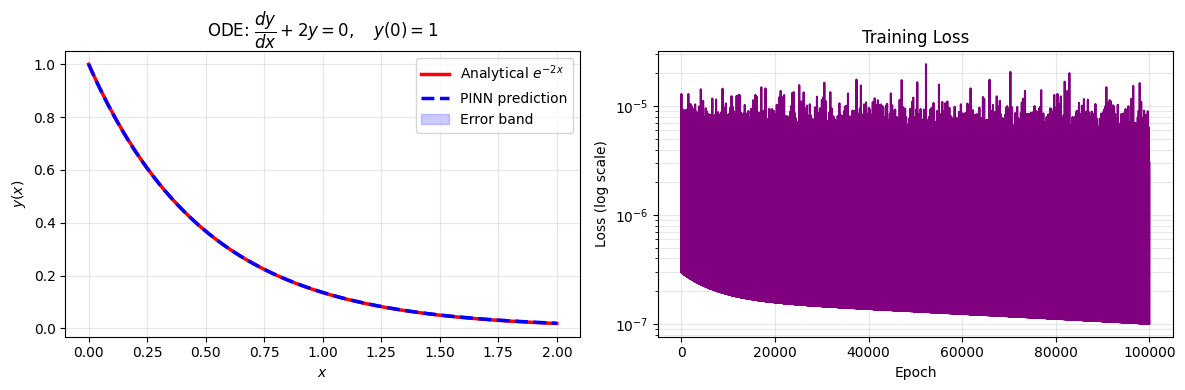

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


ax = axes[0]
ax.plot(x_test.numpy(), y_true, "r-",  lw=2.5, label=r"Analytical $e^{-2x}$")
ax.plot(x_test.numpy(), y_pred, "b--", lw=2.5, label="PINN prediction")
ax.fill_between(
    x_test.numpy().ravel(),
    y_true.ravel() - abs_err.ravel(),
    y_true.ravel() + abs_err.ravel(),
    alpha=0.2, color="blue", label="Error band",
)
ax.set_xlabel("$x$");  ax.set_ylabel("$y(x)$")
ax.set_title(r"ODE: $\dfrac{dy}{dx} + 2y = 0,\quad y(0)=1$")
ax.legend();  ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(loss_history, color="purple", lw=1.5)
ax.set_xlabel("Epoch");  ax.set_ylabel("Loss (log scale)")
ax.set_title("Training Loss")
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("pinn_class.png", dpi=150, bbox_inches="tight")
plt.show()

## Inference on extrapolated points

In [18]:
x_extrap = torch.linspace(0, 4, 200).view(-1, 1)

with torch.no_grad():
    y_extrap_pred = model(x_extrap).numpy()

y_extrap_true = np.exp(-2.0 * x_extrap.numpy())

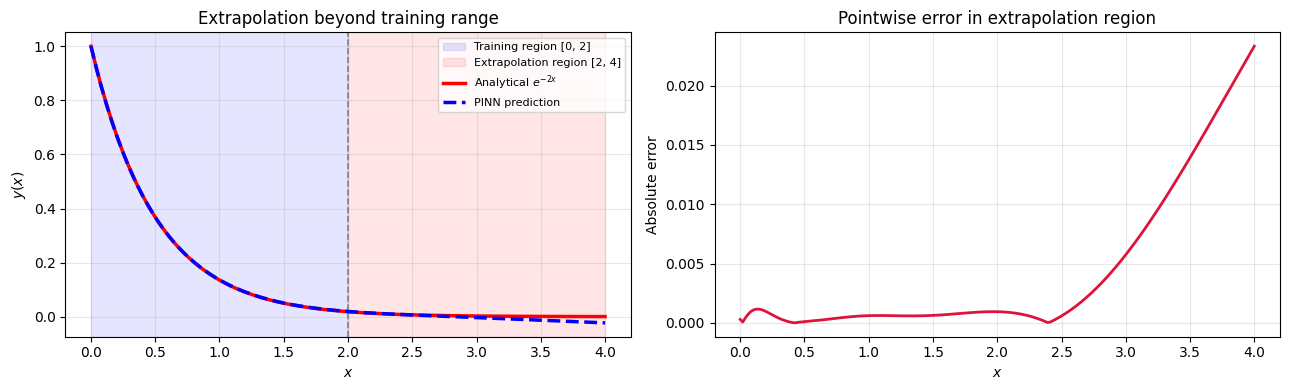

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — full picture: training + extrapolation
ax = axes[0]
ax.axvspan(0, 2, alpha=0.10, color="blue",  label="Training region [0, 2]")
ax.axvspan(2, 4, alpha=0.10, color="red",   label="Extrapolation region [2, 4]")
ax.axvline(x=2, color="gray", linestyle="--", lw=1.2)

ax.plot(x_extrap.numpy(), y_extrap_true, "r-",  lw=2.5, label=r"Analytical $e^{-2x}$")
ax.plot(x_extrap.numpy(), y_extrap_pred, "b--", lw=2.5, label="PINN prediction")

ax.set_xlabel("$x$");  ax.set_ylabel("$y(x)$")
ax.set_title("Extrapolation beyond training range")
ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)

ax = axes[1]
abs_err_extrap = np.abs(y_extrap_pred - y_extrap_true)
ax.plot(x_extrap.numpy(), abs_err_extrap, color="crimson", lw=2)
ax.set_xlabel("$x$");  ax.set_ylabel("Absolute error")
ax.set_title("Pointwise error in extrapolation region")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
print(f"Max absolute error  : {abs_err_extrap.max():.2e}")
print(f"Mean absolute error : {abs_err_extrap.mean():.2e}")
print(f"Relative L2 error   : {np.linalg.norm(y_extrap_pred - y_extrap_true) / np.linalg.norm(y_extrap_true):.2e}")

Max absolute error  : 2.33e-02
Mean absolute error : 4.29e-03
Relative L2 error   : 3.02e-02


# Example 2: Finding the Inverse of Parabola

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Generate data
N = 1000
X = np.random.random(N).astype(np.float32).reshape(-1, 1)

# Generation of Y-Data
sign = (- np.ones((N,))).astype(np.float32) ** np.random.randint(2, size=N)
Y = (np.sqrt(X.flatten()) * sign).reshape(-1, 1).astype(np.float32)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X, device=device)
Y_tensor = torch.tensor(Y, device=device)

class SimpleNN(nn.Module):
    def __init__(self, hiddendim=10):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(1, hiddendim)
        self.fc2 = nn.Linear(hiddendim, hiddendim)
        self.fc3 = nn.Linear(hiddendim, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # Linear output
        return x
    
    

## train without physics loss

In [67]:
nn_sup = SimpleNN(hiddendim=128).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(nn_sup.parameters(), lr=0.001)

# Training loop
epochs = 50
batch_size = 5

for epoch in range(epochs):
    permutation = torch.randperm(N)
    epoch_loss = 0.0
    
    for i in range(0, N, batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_tensor[indices], Y_tensor[indices]
        
        optimizer.zero_grad()
        outputs = nn_sup(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    if(epoch%10==9): print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/N:.6f}")

Epoch 10/50, Loss: 0.101022
Epoch 20/50, Loss: 0.101077
Epoch 30/50, Loss: 0.101050
Epoch 40/50, Loss: 0.101088
Epoch 50/50, Loss: 0.101045


## Let's see how did it perform

/tmp/ipykernel_228679/3389161718.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plt.plot(X_tensor.cpu().detach(), nn_sup(torch.tensor(X_tensor)).cpu().detach(),label='T', color="red")


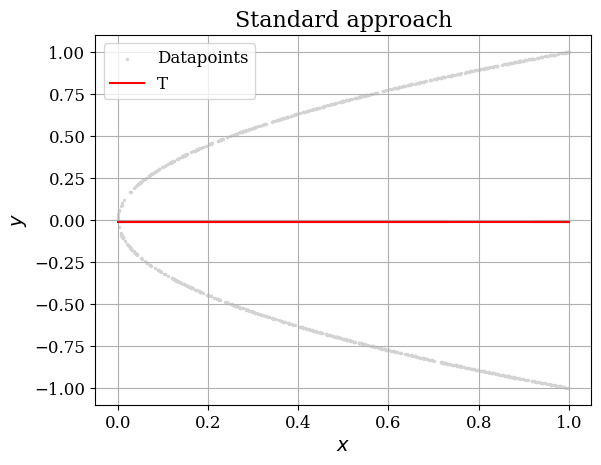

In [68]:
import matplotlib.pyplot as plt

plt.scatter(X,Y,label='Datapoints', color="lightgray", s=2)
plt.plot(X_tensor.cpu().detach(), nn_sup(torch.tensor(X_tensor)).cpu().detach(),label='T', color="red") 
plt.xlabel('$x$', )
plt.ylabel('$y$')
plt.title('Standard approach')
plt.grid('both')
plt.legend()
plt.savefig('../Lectures/figures/parabola_supervised_nn.pdf', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## Physics Approach

In [69]:
def Phi(y):
    return torch.square(y)

# custom loss function

def physics_loss(x_true, y_pred):
    return criterion(x_true, Phi(y_pred))

In [70]:
nn_dp = SimpleNN(hiddendim=128).to(device)
optimizer = optim.Adam(nn_dp.parameters(), lr=0.001)

# Training loop
batch_size = 5

for epoch in range(epochs):
    permutation = torch.randperm(N)
    epoch_loss = 0.0
    
    for i in range(0, N, batch_size):
        indices = permutation[i:i+batch_size]
        batch_x = X_tensor[indices]
        
        optimizer.zero_grad()
        outputs = nn_dp(batch_x)
        loss = physics_loss(batch_x, outputs)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    if(epoch%10==9): print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/N:.6f}")

Epoch 10/50, Loss: 0.000001
Epoch 20/50, Loss: 0.000004
Epoch 30/50, Loss: 0.000006
Epoch 40/50, Loss: 0.000002
Epoch 50/50, Loss: 0.000004


/tmp/ipykernel_228679/1022926093.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plt.plot(X_tensor.cpu().detach(), nn_dp(torch.tensor(X_tensor)).cpu().detach(), '.',label='T', color="red")


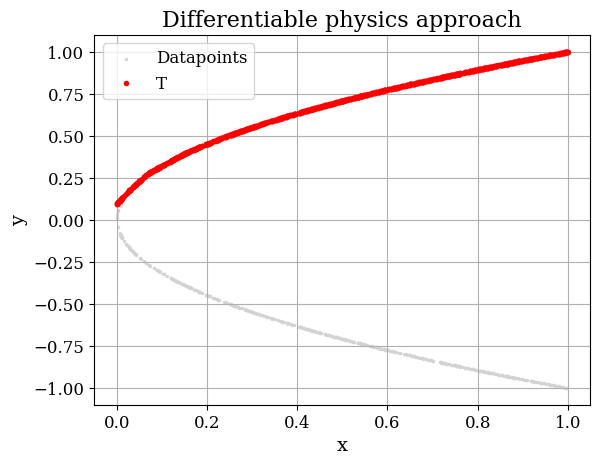

In [72]:
plt.scatter(X,Y,label='Datapoints', color="lightgray", s=2)
plt.plot(X_tensor.cpu().detach(), nn_dp(torch.tensor(X_tensor)).cpu().detach(), '.',label='T', color="red") 
plt.xlabel('x')
plt.ylabel('y')
plt.title('Differentiable physics approach')
plt.legend()
plt.grid('both')
plt.savefig('../Lectures/figures/parabola_physics_nn.pdf', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## Flow Matching Approach

In [ ]:
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

N = 5000
X = np.random.random(N).astype(np.float32).reshape(-1, 1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Generation of Y-Data
sign = (- np.ones((N,))).astype(np.float32) ** np.random.randint(2, size=N)
Y = (np.sqrt(X.flatten()) * sign).reshape(-1, 1).astype(np.float32)

class FlowMatchingDataset(Dataset):
    def __init__(self, data_x, data_y, n_samples=1000, sigma_min=1e-4):
        super().__init__()
        self.n_samples = n_samples
        self.sigma_min = sigma_min
        self.data_x = data_x
        self.data_y = data_y 

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        x0 = np.random.multivariate_normal([0.0, 0.0], np.eye(2), 1)[0]
        t = np.random.rand()  # scalar in [0,1]
        dx = self.data_x[idx] #:idx+1]
        dy_org = self.data_y[idx]# :idx+1]
        x0[0] = dx[0] # keep x value
        x1 = np.concatenate([dx,dy_org],axis=0)
        #print([self.data_x.shape,dx.shape,x1.shape])

        # sigma_min=1e-4 for numerical stability
        x_t = (1 - ( 1 - self.sigma_min) * t) * x0 + t * x1
        u_t = (x1 - x0)
        x_t = torch.tensor(x_t, dtype=torch.float32)
        t   = torch.tensor([t], dtype=torch.float32)
        u_t = torch.tensor(u_t, dtype=torch.float32)
        return x_t, t, u_t
    
    

In [ ]:
class VelocityNet(nn.Module):
    def __init__(self, hidden_dim, in_dim=2, time_dim=1, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim + time_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            
            # Note no activation on the final layer,velocity can be any sign and magnitude, so you must not squash the output.
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x, t):
        
        # time is simply appended as a raw scalar to the 2D input, giving a 3D input
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

In [29]:
batch_size = 128
epochs = 50


dataset = FlowMatchingDataset(X, Y, n_samples=N)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

nn_fm = VelocityNet(hidden_dim=128).to(device)
optimizer = optim.Adam(nn_fm.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(epochs):
    running_loss = 0.0
    for x_t, t, u_t in dataloader:
        x_t = x_t.to(device)
        t   = t.to(device)
        u_t = u_t.to(device)
        optimizer.zero_grad()
        pred_v = nn_fm(x_t, t)
        loss = criterion(pred_v, u_t)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_t.size(0)
    running_loss /= len(dataset)
    if(epoch%10==9): print(f"Epoch {epoch + 1}/{epochs}, Loss: {running_loss:.4f}")

Epoch 10/50, Loss: 0.4040
Epoch 20/50, Loss: 0.3780
Epoch 30/50, Loss: 0.3923
Epoch 40/50, Loss: 0.4023
Epoch 50/50, Loss: 0.3816


In [ ]:
# Euler integration

def integrate_flow(nn, x0, t_span=(0.0, 1.0), n_steps=100):
    trajectory = []
    t = torch.linspace(t_span[0], t_span[1], n_steps).to(x0.device)
    dt = 1./n_steps
    x_in = x0
    for i in range(n_steps):
        x0 = x0 + dt * nn(x0, torch.tensor([i/n_steps]).expand(x0.shape[0], 1).to(x0.device) )
        x0[:,0] = x_in[:,0] # condition on original x position
        trajectory.append(x0)
    return trajectory, t

# Generate samples along x, then randomize along y
n_gen = 500
x_in = torch.linspace(0.,1., n_gen).to(device)
y_in = torch.randn(n_gen).to(device) * 0.95
x0_gen = torch.stack([x_in,y_in],axis=-1)
trajectory, time_points = integrate_flow(nn_fm, x0_gen)

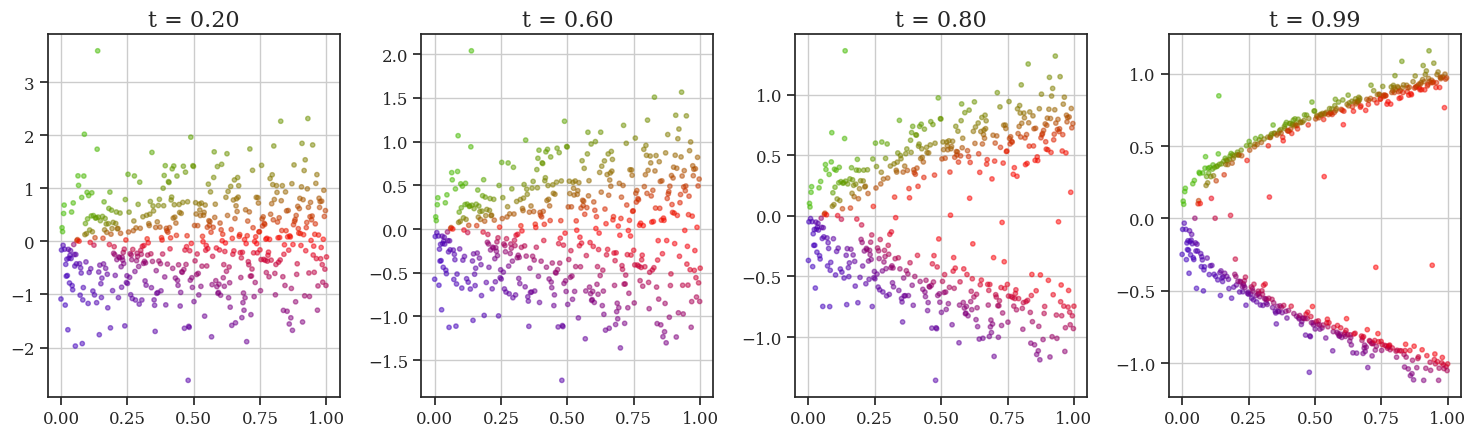

In [35]:
import seaborn as sns

def get_angle_colors(positions):
    angles = np.arctan2(positions[:, 1], positions[:, 0])
    angles_deg = (np.degrees(angles) + 360) % 360
    colors = np.zeros((len(positions), 3))
    for i, angle in enumerate(angles_deg):
        segment = int(angle / 120)
        local_angle = angle - segment * 120
        if segment == 0:    # 0 degrees to 120 degrees (R->G)
            colors[i] = [1 - local_angle/120, local_angle/120, 0]
        elif segment == 1:  # 120 degrees to 240 degrees (G->B)
            colors[i] = [0, 1 - local_angle/120, local_angle/120]
        else:               # 240 degrees to 360° (B->R)
            colors[i] = [local_angle/120, 0, 1 - local_angle/120]
    return colors

desired_times = [0.2, 0.6, 0.8, 0.99]
time_np = time_points.detach().cpu().numpy()
n_steps = len(time_np)
indices = [np.argmin(np.abs(time_np - t_val)) for t_val in desired_times]

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 5))
axes = axes.ravel()  # flatten the 2D array for easier indexing

xx, yy = np.mgrid[0:1:100j, -1:1:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])

for i, idx in enumerate(indices):
    ax = axes[i]
    x_t = trajectory[idx].detach().cpu().numpy()
    if i == 0:
        c = get_angle_colors(x_t)
    ax.scatter(x_t[:, 0], x_t[:, 1], alpha=0.5, s=10, color=c)
    ax.set_title(f"t = {time_np[idx]:.2f}")
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('../Lectures/figures/FM_probability_path_evo.pdf', dpi=200, bbox_inches='tight', facecolor='white')

plt.show()

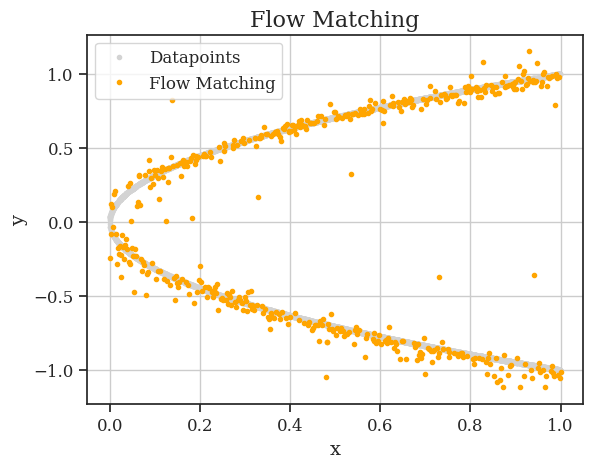

In [34]:
# Results
plt.plot(X,Y,'.',label='Datapoints', color="lightgray")
plt.plot(trajectory[-1][:,0].detach().cpu(), trajectory[-1][:,1].detach().cpu(), '.',label='Flow Matching', color="orange") 
plt.xlabel('x')
plt.ylabel('y')
plt.title('Flow Matching')
plt.legend()
plt.grid()
plt.savefig('../Lectures/figures/FM_training.pdf', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## FM + PINN

Epoch  10  FM: 0.41459   FM+PINN: 0.11694
Epoch  20  FM: 0.37365   FM+PINN: 0.09967
Epoch  30  FM: 0.38691   FM+PINN: 0.10008
Epoch  40  FM: 0.37799   FM+PINN: 0.09649
Epoch  50  FM: 0.36063   FM+PINN: 0.09324
Epoch  60  FM: 0.36191   FM+PINN: 0.09348
Epoch  70  FM: 0.37301   FM+PINN: 0.09527
Epoch  80  FM: 0.36681   FM+PINN: 0.09417
Epoch  90  FM: 0.36295   FM+PINN: 0.09354
Epoch 100  FM: 0.35735   FM+PINN: 0.09235


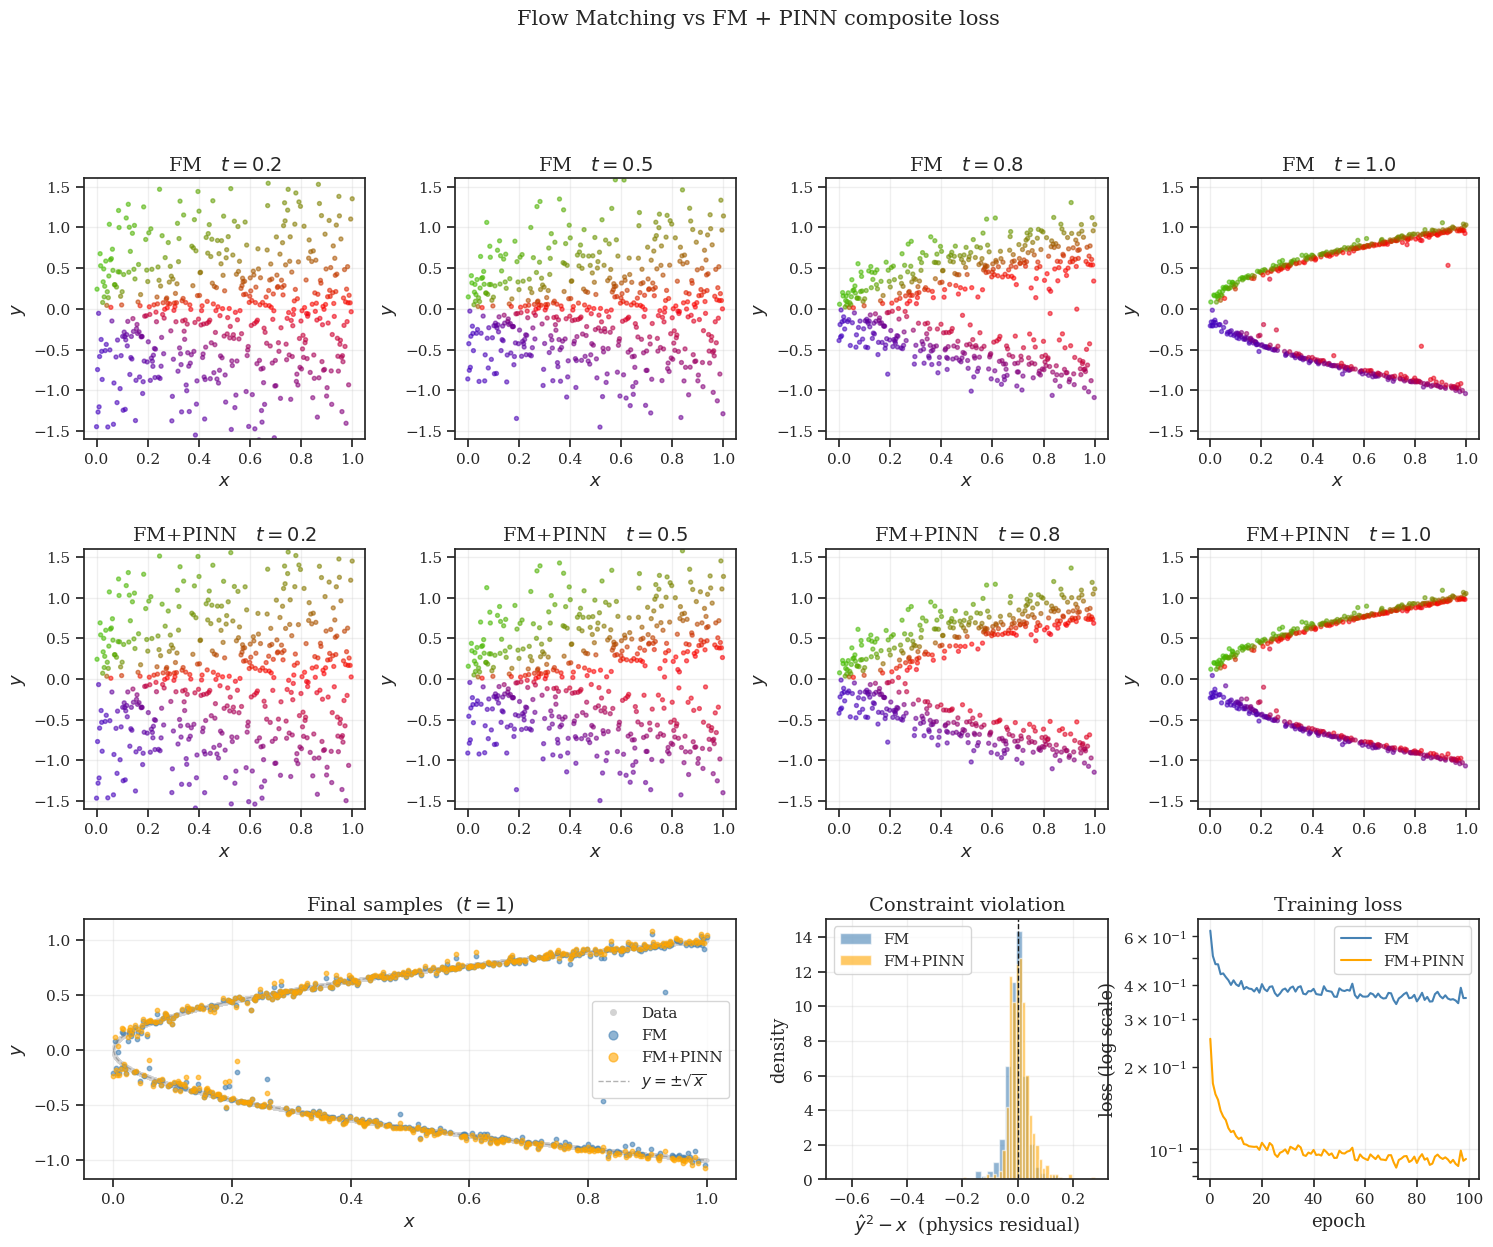

In [38]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N = 5000
X = np.random.random(N).astype(np.float32).reshape(-1, 1)
sign = (-np.ones((N,))).astype(np.float32) ** np.random.randint(2, size=N)
Y = (np.sqrt(X.flatten()) * sign).reshape(-1, 1).astype(np.float32)


class FlowMatchingDataset(Dataset):
    def __init__(self, data_x, data_y, n_samples=1000, sigma_min=1e-4):
        super().__init__()
        self.n_samples  = n_samples
        self.sigma_min  = sigma_min
        self.data_x     = data_x
        self.data_y     = data_y

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        x0       = np.random.multivariate_normal([0.0, 0.0], np.eye(2), 1)[0]
        t        = np.random.rand()
        dx       = self.data_x[idx]
        dy_org   = self.data_y[idx]
        x0[0]    = dx[0]
        x1       = np.concatenate([dx, dy_org], axis=0)
        x_t      = (1 - (1 - self.sigma_min) * t) * x0 + t * x1
        u_t      = x1 - x0
        return (torch.tensor(x_t, dtype=torch.float32),
                torch.tensor([t],  dtype=torch.float32),
                torch.tensor(u_t, dtype=torch.float32))


class VelocityNet(nn.Module):
    def __init__(self, hidden_dim, in_dim=2, time_dim=1, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim + time_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),         nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))


criterion = nn.MSELoss()

def physics_loss_fm(x_t, t, pred_v):
    x_hat_1 = x_t + (1 - t) * pred_v      # predicted endpoint (B,2)
    y_hat   = x_hat_1[:, 1]               # y-coordinate
    x_hat   = x_hat_1[:, 0]               # x-coordinate
    return criterion(y_hat ** 2, x_hat)   # enforce y^2 = x


epochs     = 100
batch_size = 128
fm_lam = 0.2
lam        = 0.8

dataset    = FlowMatchingDataset(X, Y, n_samples=N)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# plain FM
nn_fm = VelocityNet(hidden_dim=128).to(device)
opt_fm = optim.Adam(nn_fm.parameters(), lr=1e-3)

# composite FM + PINN
nn_fm_pinn = VelocityNet(hidden_dim=128).to(device)
opt_fmp    = optim.Adam(nn_fm_pinn.parameters(), lr=1e-3)

hist_fm   = []
hist_fmp  = []

for epoch in range(epochs):
    loss_fm_ep = loss_fmp_ep = 0.0

    for x_t, t, u_t in dataloader:
        x_t, t, u_t = x_t.to(device), t.to(device), u_t.to(device)

        # ── plain FM ──
        opt_fm.zero_grad()
        pv      = nn_fm(x_t, t)
        loss    = criterion(pv, u_t)
        loss.backward();  opt_fm.step()
        loss_fm_ep += loss.item() * x_t.size(0)

        # ── FM + PINN ──
        opt_fmp.zero_grad()
        pv2       = nn_fm_pinn(x_t, t)
        lf        = criterion(pv2, u_t)
        lp        = physics_loss_fm(x_t, t, pv2)
        loss2     = fm_lam* lf + lam * lp
        loss2.backward();  opt_fmp.step()
        loss_fmp_ep += loss2.item() * x_t.size(0)

    hist_fm.append(loss_fm_ep   / N)
    hist_fmp.append(loss_fmp_ep / N)

    if epoch % 10 == 9:
        print(f"Epoch {epoch+1:3d}  FM: {hist_fm[-1]:.5f}   FM+PINN: {hist_fmp[-1]:.5f}")


def integrate_flow(net, x0, n_steps=200):
    trajectory = []
    dt   = 1.0 / n_steps
    x_in = x0.clone()
    with torch.no_grad():
        for k in range(n_steps):
            tk  = torch.tensor([k / n_steps]).expand(x0.shape[0], 1).to(x0.device)
            x0  = x0 + dt * net(x0, tk)
            x0[:, 0] = x_in[:, 0]          # re-impose x-conditioning
            trajectory.append(x0.clone())
    return trajectory

n_gen   = 500
x_in    = torch.linspace(0., 1., n_gen).to(device)
y_in    = torch.randn(n_gen).to(device) * 0.95
x0_gen  = torch.stack([x_in, y_in], dim=-1)

traj_fm   = integrate_flow(nn_fm,      x0_gen.clone())
traj_fmp  = integrate_flow(nn_fm_pinn, x0_gen.clone())


def angle_colors(pos):
    ang  = (np.degrees(np.arctan2(pos[:, 1], pos[:, 0])) + 360) % 360
    cols = np.zeros((len(ang), 3))
    for i, a in enumerate(ang):
        seg   = int(a / 120)
        la    = a - seg * 120
        if   seg == 0: cols[i] = [1 - la/120, la/120, 0]
        elif seg == 1: cols[i] = [0, 1 - la/120, la/120]
        else:          cols[i] = [la/120, 0, 1 - la/120]
    return cols


snap_times = [0.2, 0.5, 0.8, 1.0]
n_steps_   = len(traj_fm)
time_arr   = np.linspace(0, 1, n_steps_)
snap_idx   = [np.argmin(np.abs(time_arr - tv)) for tv in snap_times]

fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.42, wspace=0.32)

#  Row 0: FM snapshots
init_pos = traj_fm[0].cpu().numpy()
c0       = angle_colors(init_pos)

for col, (idx, tv) in enumerate(zip(snap_idx, snap_times)):
    ax  = fig.add_subplot(gs[0, col])
    pos = traj_fm[idx].cpu().numpy()
    ax.scatter(pos[:, 0], pos[:, 1], s=8, alpha=0.55, color=c0)
    ax.set_title(f"FM   $t={tv:.1f}$")
    ax.set_xlim(-0.05, 1.05);  ax.set_ylim(-1.6, 1.6)
    ax.set_xlabel("$x$");      ax.set_ylabel("$y$")
    ax.grid(True, alpha=0.3)

#  Row 1: FM+PINN snapshots 
init_pos2 = traj_fmp[0].cpu().numpy()
c1        = angle_colors(init_pos2)

for col, (idx, tv) in enumerate(zip(snap_idx, snap_times)):
    ax  = fig.add_subplot(gs[1, col])
    pos = traj_fmp[idx].cpu().numpy()
    ax.scatter(pos[:, 0], pos[:, 1], s=8, alpha=0.55, color=c1)
    ax.set_title(f"FM+PINN   $t={tv:.1f}$")
    ax.set_xlim(-0.05, 1.05);  ax.set_ylim(-1.6, 1.6)
    ax.set_xlabel("$x$");      ax.set_ylabel("$y$")
    ax.grid(True, alpha=0.3)

#  Row 2 left: final overlay 
ax_final = fig.add_subplot(gs[2, :2])
ax_final.plot(X, Y, '.', color='lightgray', ms=4, label='Data', zorder=1)

fin_fm  = traj_fm[-1].cpu().numpy()
fin_fmp = traj_fmp[-1].cpu().numpy()

ax_final.scatter(fin_fm[:,0],  fin_fm[:,1],  s=10, alpha=0.6,
                color='steelblue', label='FM',       zorder=2)
ax_final.scatter(fin_fmp[:,0], fin_fmp[:,1], s=10, alpha=0.6,
                color='orange',    label='FM+PINN',  zorder=3)

# reference parabola
xr = np.linspace(0, 1, 300)
ax_final.plot(xr,  np.sqrt(xr), '--', color='gray', lw=1, alpha=0.6, label='$y=\\pm\\sqrt{x}$')
ax_final.plot(xr, -np.sqrt(xr), '--', color='gray', lw=1, alpha=0.6)

ax_final.set_xlabel("$x$");  ax_final.set_ylabel("$y$")
ax_final.set_title("Final samples  ($t=1$)")
ax_final.legend(markerscale=2);  ax_final.grid(True, alpha=0.3)

#  Row 2 right: physics residual 
ax_res = fig.add_subplot(gs[2, 2])
res_fm  = (fin_fm[:,1]**2  - fin_fm[:,0])
res_fmp = (fin_fmp[:,1]**2 - fin_fmp[:,0])

ax_res.hist(res_fm,  bins=40, alpha=0.6, color='steelblue', label='FM',      density=True)
ax_res.hist(res_fmp, bins=40, alpha=0.6, color='orange',    label='FM+PINN', density=True)
ax_res.axvline(0, color='k', lw=1, ls='--')
ax_res.set_xlabel("$\\hat{y}^2 - x$  (physics residual)")
ax_res.set_ylabel("density")
ax_res.set_title("Constraint violation")
ax_res.legend();  ax_res.grid(True, alpha=0.3)

#  Row 2 far right: training loss 
ax_loss = fig.add_subplot(gs[2, 3])
ax_loss.semilogy(hist_fm,  color='steelblue', label='FM')
ax_loss.semilogy(hist_fmp, color='orange',    label='FM+PINN')
ax_loss.set_xlabel("epoch");  ax_loss.set_ylabel("loss (log scale)")
ax_loss.set_title("Training loss")
ax_loss.legend();  ax_loss.grid(True, alpha=0.3)

fig.suptitle("Flow Matching vs FM + PINN composite loss", fontsize=15, y=1.01)
plt.savefig("../Lectures/figures/fm_pinn_results.pdf", dpi=150, bbox_inches='tight')
plt.show()